# Clustering Models

# Problem 1

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [94]:
orig_data = pd.read_csv('/content/HW11-ClusteringData.csv')
# data.head()

## Part (a)
Plot the data points using different colors for each label.

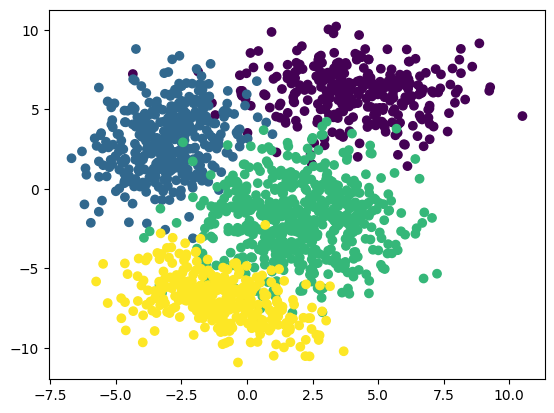

In [95]:
# Plot all the points on a graph with the first column as X-axis and second column as Y-axis and third column as label
# This gives us the true distribution
plt.scatter(orig_data.iloc[:, 0], orig_data.iloc[:, 1], c=orig_data.iloc[:, 2])
plt.show()

## Part (b)
Cluster the data points using k-means clustering for k ∈ {2,3,4,5,6,7}.

Calculate the silhouette coefficient for every k using both Euclidean distance and Manhattan distance. Plot the data points and determine the optimal value of k for each type of distance calculation.

In [96]:
# Convergence Check Functions (Separated here in case I want to change it from 0 difference to minimum difference.)

# No reassignments or minimum reassignments
def converge_assign(old_points, new_points):
  # Check if the old assignments are the same as the new assignments, return true to break the loop
  if np.array_equal(old_points, new_points):
    return True
  else:
    return False

# No change of centroids of minimum change of centroids
def converge_centroids(old_centroids, new_centroids):
  # Check if the old centroids are the same as the new centroids, return true to break the loop
  if np.array_equal(old_centroids, new_centroids):
    return True
  else:
    return False

# No decrease or minimum decrease in sum of squared error
def converge_sse(old_sse, new_sse):
  # Check if the old SSE is the same as the new SSE, return true to break the loop
  if old_sse >= new_sse:
    return False
  else:
    return True

In [97]:
# Assignment function
def assign(data, centroids):
  # For each data point x, assign x to the nearest centroid based on Euclidean distance and update cluster assignment
  distances = np.linalg.norm(data[:, np.newaxis, :] - centroids, axis=2)
  return np.argmin(distances, axis=1)

# Update centroid function and calculate the SSE using the new centroids and return both
def update_centroids(data, labels):
  # Calculate the mean of the new assignments and return them as the new centroids
  centroids = np.array([data[labels == i].mean(axis=0) for i in range(k)])

  # Calculate the sum of squared errors for each cluster (This is used to check for convergence)
  sse = np.sum((data - centroids[labels])**2)

  return centroids, sse

In [98]:
# Store the resulting centroids for each k
kCentroids = []

# Store the final labels for each point respective of k
kLabels = []

# Convert pandas dataframe into a numpy array
data = orig_data.to_numpy()

# Separate first two feature columns from third label column
data, realLabels = data[:, :2], data[:, 2]

# Loop through each number of centroids k
for k in range(2, 8):

  # Initialize k centroids by randomly choosing k points from data
  oldCentroids = data[np.random.choice(len(data), k, replace=False)]

  # Create initial assignments, and sse
  newLabels = assign(data, oldCentroids)
  newCentroids, oldSSE = update_centroids(data, newLabels)

  # Switch old labels with new labels
  oldLabels = newLabels.copy()

  # Repeat until convergence (Minimum reassignments, change of centroids, or sum squared error)
  while True:

    # Assign each point to a centroid
    newLabels = assign(data, newCentroids)

    # Update the values of each centroid
    newCentroids, newSSE = update_centroids(data, newLabels)

    # Check for convergence
    if converge_assign(oldLabels, newLabels) or converge_centroids(oldCentroids, newCentroids) or converge_sse(oldSSE, newSSE):
      break

    # Update the old centroids, labels, sse
    oldCentroids = newCentroids.copy()
    oldLabels = newLabels.copy()
    oldSSE = newSSE

  # Store the resulting centroids and labels for each k
  kCentroids.append(newCentroids)
  kLabels.append(newLabels)

# print(kCentroids)
# print(len(kLabels[0]))

In [99]:
print(kCentroids[2])

[[ 2.29354938 -1.81932211]
 [-0.78885112 -6.66036817]
 [ 4.29916903  5.83665005]
 [-2.82005957  2.97555937]]


[0.4532488338179635, 0.4814924934459492, 0.5030859391197188, 0.45464836927771585, 0.4104628671784271, 0.37853791514654117]
[0.44997530265058594, 0.46893005710994473, 0.5051073424824516, 0.45586780051712367, 0.40790657649662704, 0.3753432791808906]


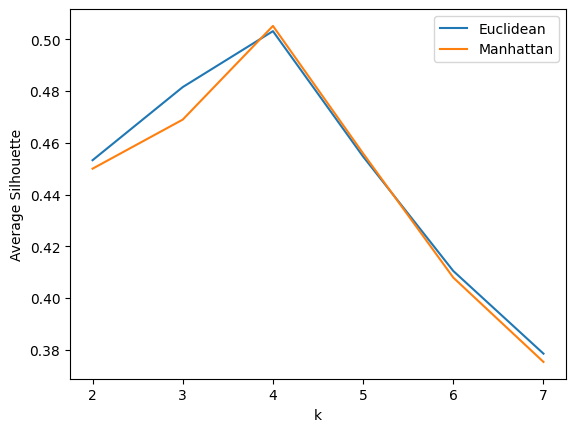

In [100]:
# Calculate silhouette coefficient
def silhouette(data, labels):

  N = len(data)
  uniqLabels = np.unique(labels)  # This is already 0 indexed in terms of label names
  silhouetteScoresEuclidean = np.zeros(len(data))
  silhouetteScoresManhattan = np.zeros(len(data))

  # Preprocess the clusters into a dictionary to speed up look up
  clusters = {}
  for i in uniqLabels:
    clusters[i] = data[labels == i]

  # Loop through all points in the dataset
  for i, point in enumerate(data):
    # Get cluster of current point
    cluster = labels[i]

    # Get Same Cluster
    sameCluster = clusters[cluster].copy()

    # Exclude the current point in the same cluster
    sameCluster = sameCluster[~(sameCluster == point).all(axis=1)]

    # Calculate Alpha
    alphaEuclidean = np.mean(np.linalg.norm(sameCluster - point, axis=1))
    alphaManhattan = np.mean(np.abs(sameCluster - point))

    # Calculate Beta
    betaEuclidean = np.inf  # for initial min functions
    betaManhattan = np.inf
    for otherCluster, otherPoints in clusters.items():
      # Exclude the cluster of this point
      if otherCluster != cluster:
        betaEuclidean = min(betaEuclidean, np.mean(np.linalg.norm(otherPoints - point, axis=1)))
        betaManhattan = min(betaManhattan, np.mean(np.abs(otherPoints - point)))

    # Calculate Silhouette Score using Euclidean Distance
    silhouetteScoresEuclidean[i] = (betaEuclidean - alphaEuclidean) / max(alphaEuclidean, betaEuclidean)

    # Calculate Silhouette Score using Manhattan Distance
    silhouetteScoresManhattan[i] = (betaManhattan - alphaManhattan) / max(alphaManhattan, betaManhattan)

  return np.mean(silhouetteScoresManhattan), np.mean(silhouetteScoresEuclidean)

# Run the clusters to get the results
averageSilhouetteEuclidean = []
averageSilhouetteManhattan = []
for labels in kLabels:
  a, b = silhouette(data, labels)
  averageSilhouetteEuclidean.append(b)
  averageSilhouetteManhattan.append(a)

print(averageSilhouetteEuclidean)
print(averageSilhouetteManhattan)

# Plot a line graph using averageSilhouettes
plt.plot(range(2, 8), averageSilhouetteEuclidean, label='Euclidean')
plt.plot(range(2, 8), averageSilhouetteManhattan, label='Manhattan')
plt.xlabel('k')
plt.ylabel('Average Silhouette')
plt.legend()
plt.show()

### Optimal k
The optimal value of k seems to be 4 for both Euclidean and Manhattan distance Silhouette Coefficient.

## Part (c)
Use Expectation Maximization algorithm to estimate π_k and μ_k for k ∈ {1,2,3,4}.

In [101]:
# Expectation Step function
def expectation_step(data, pi, mu, sigma):

  # Get length and number of features
  x, y = data.shape

  # Initialize the posterior probabilities
  posterior = np.zeros((x, 4))

  # Loop over each point or row of features
  for i in range(x):

    # Loop over summation of mixture of gaussians
    likelihood = 0
    for j in range(4):
      tmp = pi[j] * multivariate_normal.pdf(data[i], mu[j], sigma[j])

      posterior[i, j] = tmp

      likelihood += tmp

    posterior[i, :] /= likelihood

  return posterior

# Maximization Step function
def maximization_step(data, posterior):

  # Get length and number of features
  x, y = data.shape

  # Initialize updated pi, mu, sigma
  pi, mu, sigma = np.zeros(4), np.zeros((4, y)), np.zeros((4, y, y))

  # Loop over each k
  for k in range(4):

    # Add up the probabilities for each point for each k forming an "expected value" of sorts to weight the results
    N_l = np.sum(posterior[:, k])

    # Update pi_k
    pi[k] = N_l / x

    # Update mu_k
    mu[k] = np.sum(posterior[:, k][:, np.newaxis] * data, axis=0) / N_l

    # Update sigma_k (covariance matrix)
    sigma[k] = np.zeros((y, y))
    for i in range(x):
      sigma[k] += posterior[i, k] * np.outer(data[i] - mu[k], data[i] - mu[k])
    sigma[k] /= N_l

  return pi, mu, sigma

# LogLikelihood Evaluation function
def log_likelihood(data, pi, mu, sigma):

  # Get length and number of features
  x, y = data.shape

  # Initialize
  loglikelihood = 0

  # Loop over each point or row of features
  for i in range(x):

    # This is the summation for the mixture of gaussians on the slides, pi is the mixing coefficient and the function is the probability of data[i] given mu[j] and sigma[j]
    loglikelihood_point = 0
    for j in range(4):
      loglikelihood_point += pi[j] * multivariate_normal.pdf(data[i], mu[j], sigma[j])

    # This is the product turned summation because of loglikelihood
    loglikelihood += np.log(loglikelihood_point)

  return loglikelihood

In [102]:
from re import M
# Initialize Parameters
pi = np.ones(4) / 4
mu = kCentroids[2] # Changed to initializing with previously gotten centroids because it was taking too long to converge with random initialization
sigma = np.array([np.cov(data.T) for _ in range(4)])
# print(pi)
# print(mu)
# print(sigma)

# Evaluate LogLikelihood
oldLoglikelihood = log_likelihood(data, pi, mu, sigma)
# print(loglikelihood)

# test = expectation_step(data, pi, mu, sigma)
# print(sum(test[1598])) # The sum of each row to evaluate to 1

# test2 = maximization_step(data, test)
# print(test2)

# Loop until stopping criterion is met
for t in range(1000): # Maximum of 1000 iterations

  # Expectation Step
  posterior = expectation_step(data, pi, mu, sigma)

  # Maximization Step
  pi, mu, sigma = maximization_step(data, posterior)

  # Evaluate LogLikelihood
  newLoglikelihood = log_likelihood(data, pi, mu, sigma)

  # Check for convergence
  check = np.abs(newLoglikelihood - oldLoglikelihood)
  if check < 1e-6:
    print("Converged")
    break
  else:
    print(f"Iteration {t}: {check}")

  # Move new loglikelihood
  oldLoglikelihood = newLoglikelihood

# Print out the real values alongside the estimated values for comparison
print("\n\nOrder of numbers might be wrong.")
print("Esitmated pi_k:", pi)
print("Real pi_k:", [0.1875, 0.25, 0.3438, 0.2188])
print("\nEsimated mu_k:", mu)
print("Real mu_k:", [[4, 6], [-3, 3], [2, -2], [-1, -7]])
# print(sigma)

Iteration 0: 390.29616377507045
Iteration 1: 100.1343601665576
Iteration 2: 80.22846709635996
Iteration 3: 36.99704795327307
Iteration 4: 19.44730907659323
Iteration 5: 16.675997155083678
Iteration 6: 15.661217246251908
Iteration 7: 13.088683039091848
Iteration 8: 10.51682634871213
Iteration 9: 10.15172838586659
Iteration 10: 11.79188397877624
Iteration 11: 14.122934275261287
Iteration 12: 15.31675049767
Iteration 13: 13.658967819654208
Iteration 14: 9.560174625668878
Iteration 15: 5.449297328805187
Iteration 16: 2.799603010487772
Iteration 17: 1.4241660917541594
Iteration 18: 0.7504465277161216
Iteration 19: 0.41462627711916866
Iteration 20: 0.2405383929144591
Iteration 21: 0.14627996125818754
Iteration 22: 0.09293058132971055
Iteration 23: 0.06137269868304429
Iteration 24: 0.04189060341559525
Iteration 25: 0.029374907295277808
Iteration 26: 0.021043384182121372
Iteration 27: 0.015325673219194869
Iteration 28: 0.0113020786720881
Iteration 29: 0.008413456023845356
Iteration 30: 0.00630

# Contour Plot


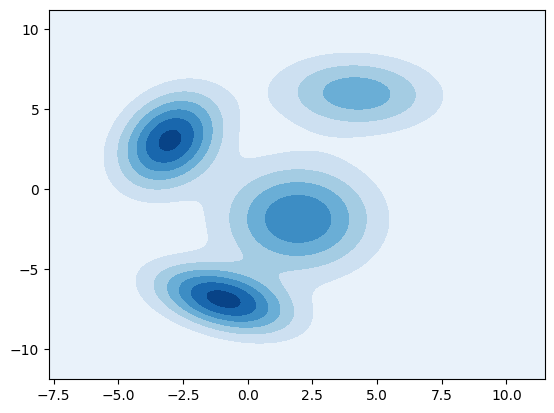

In [103]:
# Create grid
xMin, xMax = data[:, 0].min() - 1, data[:, 0].max() + 1
yMin, yMax = data[:, 1].min() - 1, data[:, 1].max() + 1
x, y = np.meshgrid(np.arange(xMin, xMax, 0.02), np.arange(yMin, yMax, 0.02))
grid = np.c_[x.ravel(), y.ravel()]

# Calculate GMM PDF
pdf = np.zeros(grid.shape[0])
for k in range(4):
  pdf += pi[k] * multivariate_normal.pdf(grid, mu[k], sigma[k])

# Reshape PDF to original grid shape
pdf = pdf.reshape(x.shape)

# Plot contour plot, Uncomment the middle line to overlay the scatterplot
plt.contourf(x, y, pdf, cmap='Blues')
# plt.scatter(data[:, 0], data[:, 1], c=realLabels)
plt.show()